# Retrieval Evaluation for Semantic Search & RAG

## Objective

In this notebook, we will:

- Build a small semantic search dataset
- Create ground truth labels
- Simulate retrieval results
- Calculate Precision@K
- Calculate Recall@K
- Analyze retrieval performance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import faiss

In [3]:
documents = {
    "D1":"Machine Learning is a subset of Artificial Intelligence.",
    "D2":"Deep Learning uses neural networks.",
    "D3":"Python is widely used for AI development.",
    "D4":"Diabetes symptoms include excessive thirst.",
    "D5":"Heart diseases affect the cardiovascular system.",
    "D6":"Vector databases store embeddings.",
    "D7":"FAISS performs efficient vector similarity search.",
    "D8":"Semantic Search retrieves documents based on meaning.",
    "D9":"Precision@K evaluates retrieval quality.",
    "D10":"Recall@K measures retrieval coverage."
}

In [4]:
queries = {
    "Q1":"What is Machine Learning?",
    "Q2":"Explain Semantic Search",
    "Q3":"What is Precision@K?",
    "Q4":"Symptoms of Diabetes"
}

In [5]:
ground_truth = {
    "Q1":["D1"],
    "Q2":["D8","D6"],
    "Q3":["D9"],
    "Q4":["D4"]
}

In [6]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [7]:
doc_ids = list(documents.keys())
doc_text = list(documents.values())

doc_embeddings = model.encode(
    doc_text,
    convert_to_numpy=True
)

In [8]:
dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(doc_embeddings)

print("Total vectors:",index.ntotal)

Total vectors: 10


In [9]:
def retrieve(query,k=5):

    embedding = model.encode([query])

    distances,indices=index.search(
        embedding.astype("float32"),k
    )

    results=[]

    for i in indices[0]:
        results.append(doc_ids[i])

    return results

In [10]:
retrieve("Explain Semantic Search")

['D8', 'D7', 'D9', 'D1', 'D6']

In [11]:
def precision_at_k(retrieved,relevant,k):

    retrieved=retrieved[:k]

    relevant_count=0

    for doc in retrieved:

        if doc in relevant:
            relevant_count+=1

    return relevant_count/k

In [12]:
def recall_at_k(retrieved,relevant,k):

    retrieved=retrieved[:k]

    relevant_count=0

    for doc in retrieved:

        if doc in relevant:
            relevant_count+=1

    return relevant_count/len(relevant)

In [13]:
results=[]

for qid,query in queries.items():

    retrieved=retrieve(query)

    precision=precision_at_k(
        retrieved,
        ground_truth[qid],
        5
    )

    recall=recall_at_k(
        retrieved,
        ground_truth[qid],
        5
    )

    results.append(
        [qid,precision,recall]
    )

df=pd.DataFrame(
    results,
    columns=[
        "Query",
        "Precision@5",
        "Recall@5"
    ]
)

df

,Query,Precision@5,Recall@5
0,Q1,0.2,1.0
1,Q2,0.4,1.0
2,Q3,0.2,1.0
3,Q4,0.2,1.0


In [14]:
print("Average Precision:",df["Precision@5"].mean())

print("Average Recall:",df["Recall@5"].mean())

Average Precision: 0.25
Average Recall: 1.0


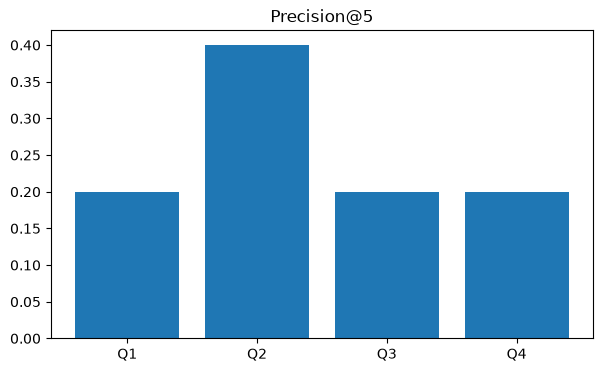

In [15]:
plt.figure(figsize=(7,4))

plt.bar(
    df["Query"],
    df["Precision@5"]
)

plt.title("Precision@5")

plt.show()

# Observations

- Precision measures retrieval accuracy.
- Recall measures retrieval coverage.
- Higher precision means fewer irrelevant documents.
- Higher recall means more relevant documents are found.